# Phase 2 — Baseline models

Goal: train an unsupervised baseline (IsolationForest) and a supervised baseline (XGBoost) on an early time slice, and evaluate both on a later time slice — never a random split, since that would let the model see the "future" during training and would hide any concept drift, which is the entire point of this project.

## Time-based split

From Phase 1 we know the dataset spans two real calendar days (clear day/night volume cycle, day boundary around hour 24). We'll train on **day 1** (`Hour < 24`) and test on **day 2** (`Hour >= 24`) — this mirrors how the system would actually be used (train on historical data, evaluate as if deployed the next day), and it's a clean, explainable split rather than an arbitrary row-count cutoff.

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import load_raw
from src.features import FEATURE_COLS, add_hour

df = add_hour(load_raw())

train_df = df[df['Hour'] < 24].reset_index(drop=True)
test_df = df[df['Hour'] >= 24].reset_index(drop=True)

X_train, y_train = train_df[FEATURE_COLS], train_df['Class']
X_test, y_test = test_df[FEATURE_COLS], test_df['Class']

print(f'train: {len(train_df)} rows, {y_train.sum()} fraud ({y_train.mean():.4%})')
print(f'test:  {len(test_df)} rows, {y_test.sum()} fraud ({y_test.mean():.4%})')

train: 144786 rows, 281 fraud (0.1941%)
test:  140021 rows, 211 fraud (0.1507%)


## Baseline 1: IsolationForest (unsupervised)

IsolationForest builds random trees that repeatedly split the data; points that get isolated into their own leaf in very few splits are "easy to separate from the crowd" and get scored as more anomalous. It never sees `y_train` — it only learns what the *bulk* of transactions look like. We use `score_samples` (higher = more normal) and flip its sign so higher = more suspicious, matching the convention we'll use for XGBoost's fraud probability.

In [2]:
from src.models import fit_isolation_forest, isolation_forest_scores

iso_forest = fit_isolation_forest(X_train)
iso_scores_test = isolation_forest_scores(iso_forest, X_test)

print('IsolationForest fit on', len(X_train), 'training rows (no labels used).')
print('example anomaly scores (test set):', iso_scores_test[:5])

IsolationForest fit on 144786 training rows (no labels used).
example anomaly scores (test set): [0.39411007 0.43723124 0.42778536 0.41784246 0.37922643]


## Baseline 2: XGBoost (supervised)

XGBoost trains a sequence of small decision trees, each one correcting the previous trees' mistakes. Since fraud is only ~0.19% of the training rows, a model trained normally would find it "cheap" to just predict "not fraud" every time. `scale_pos_weight` tells it that missing a fraud example should count roughly as costly as `(negative count / positive count)` false alarms during training, so it's actually pushed to learn the fraud pattern instead of ignoring it. Note: this is a training-time weighting, not the same as the business cost matrix we'll build in Phase 4 — it just prevents the model from collapsing to the trivial solution.

In [3]:
from src.models import fit_xgboost, xgboost_scores

xgb_model = fit_xgboost(X_train, y_train)
xgb_scores_test = xgboost_scores(xgb_model, X_test)

print('example fraud probabilities (test set):', xgb_scores_test[:5])

example fraud probabilities (test set): [3.5484709e-06 2.8299339e-05 1.6780955e-03 4.3060272e-03 1.5134498e-04]


## Evaluation — why not accuracy or plain F1

We already showed in Phase 1 that accuracy is meaningless here (a do-nothing model scores 99.8%). F1 has a different problem: it collapses precision and recall into one number at a single, arbitrary threshold (usually 0.5), which doesn't correspond to any real business decision and hides the tradeoff entirely.

Instead we use:
- **PR-AUC** (average precision): summarizes precision vs. recall across *every* threshold at once — a model that's only good at one lucky threshold won't score well here.
- **Recall at precision >= 0.9**: a concrete, business-readable question — "if we insist that at least 9 out of 10 alerts we raise are real fraud, how much of the actual fraud do we still catch?"
- A confusion matrix at one illustrative threshold, just to make the raw counts concrete (not as the main metric).

In [4]:
from sklearn.metrics import average_precision_score, precision_recall_curve


def recall_at_precision(y_true, scores, min_precision=0.9):
    precision, recall, _ = precision_recall_curve(y_true, scores)
    valid = precision >= min_precision
    return recall[valid].max() if valid.any() else 0.0


model_scores = {'IsolationForest': iso_scores_test, 'XGBoost': xgb_scores_test}

results_df = pd.DataFrame({
    name: {
        'PR-AUC': average_precision_score(y_test, scores),
        'Recall @ Precision>=0.9': recall_at_precision(y_test, scores, 0.9),
    }
    for name, scores in model_scores.items()
}).T

results_df

,PR-AUC,Recall @ Precision>=0.9
IsolationForest,0.097828,0.000000
XGBoost,0.785309,0.668246


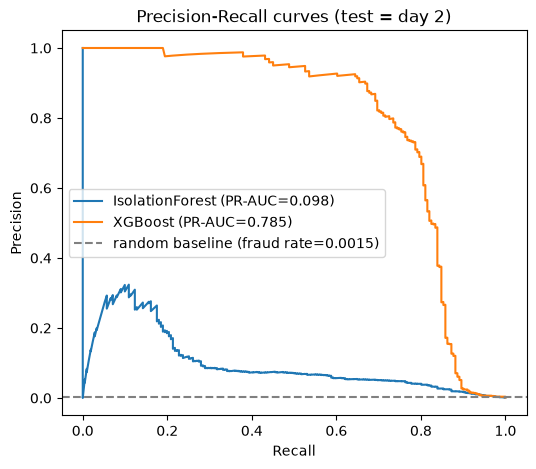

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
for name, scores in model_scores.items():
    precision, recall, _ = precision_recall_curve(y_test, scores)
    ax.plot(recall, precision, label=f'{name} (PR-AUC={average_precision_score(y_test, scores):.3f})')

ax.axhline(y_test.mean(), color='gray', linestyle='--', label=f'random baseline (fraud rate={y_test.mean():.4f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall curves (test = day 2)')
ax.legend()
plt.show()

## Confusion matrices at one illustrative threshold

Just to make the tradeoff concrete in raw counts — XGBoost at its default 0.5 probability cutoff, IsolationForest at its own built-in anomaly cutoff (`contamination='auto'`). These thresholds are arbitrary; Phase 4 replaces them with a cost-minimizing threshold instead.

In [6]:
from sklearn.metrics import confusion_matrix

xgb_preds = (xgb_scores_test >= 0.5).astype(int)
print('XGBoost @ threshold 0.5')
print(confusion_matrix(y_test, xgb_preds))

iso_preds_raw = iso_forest.predict(X_test)  # -1 = anomaly, 1 = normal
iso_preds = (iso_preds_raw == -1).astype(int)
print('\nIsolationForest @ its own contamination="auto" cutoff')
print(confusion_matrix(y_test, iso_preds))

XGBoost @ threshold 0.5
[[139678    132]
 [    39    172]]



IsolationForest @ its own contamination="auto" cutoff
[[133542   6268]
 [    34    177]]


## Summary

- **XGBoost (PR-AUC 0.785) massively outperforms IsolationForest (PR-AUC 0.098)** on this time-based split. This makes sense: XGBoost gets to learn directly from labeled fraud examples, while IsolationForest only knows "normal vs. unusual" without ever being told what fraud actually looks like.
- At its default threshold, XGBoost catches 172/211 frauds (81.5% recall) with 132 false alarms (56.6% precision). IsolationForest's built-in threshold catches slightly more frauds (177/211, 84%) but drowns them in 6,268 false alarms (2.7% precision) — in practice, unusable for a human reviewer.
- XGBoost can hit **66.8% recall while keeping precision >= 90%** — i.e. we could catch two-thirds of day-2 fraud while keeping 9 out of 10 alerts genuine. IsolationForest can never reach 90% precision at any threshold on this data.
- This is our **static baseline**: one model, trained once on day 1, evaluated on day 2. Phase 3 tests whether this performance holds up if we kept extending forward in time without ever retraining — which is the actual concept-drift question.